In [ ]:
!pip install optuna

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score

import optuna

In [ ]:
df = pd.read_csv("quikr_car.csv")
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [ ]:
df = df[df['year'].str.isnumeric()]
df['year'] = df['year'].astype(int)

In [ ]:
df = df[df['Price'] != 'Ask For Price']

df['Price'] = df['Price'].str.replace(',', '')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')  #convert data into int,float,nan
df['Price'] = df['Price'].astype(int)

In [ ]:
df['kms_driven'] = df['kms_driven'].str.replace('kms', '', regex=False)
df['kms_driven'] = df['kms_driven'].str.replace(',', '', regex=False)

In [ ]:
#remove extra space
df['kms_driven'] = df['kms_driven'].str.strip()

# Convert to numeric
df['kms_driven'] = pd.to_numeric(df['kms_driven'], errors='coerce')

# Drop invalid rows
df = df[df['kms_driven'].notnull()]

# Convert to int
df['kms_driven'] = df['kms_driven'].astype(int)

In [ ]:
df[df['fuel_type'].isnull()]

,name,company,year,Price,kms_driven,fuel_type
132,Toyota Corolla,Toyota,2009,275000,26000,NaN


In [ ]:
df.dropna(subset=['fuel_type'], inplace=True)            #df[~df['fuel_type'].isna()]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 816 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        816 non-null    object
 1   company     816 non-null    object
 2   year        816 non-null    int64 
 3   Price       816 non-null    int64 
 4   kms_driven  816 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(3), object(3)
memory usage: 44.6+ KB


In [ ]:
df['company'].unique()

array(['Hyundai', 'Mahindra', 'Ford', 'Maruti', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'Tata', 'Volkswagen',
       'Chevrolet', 'Mini', 'BMW', 'Nissan', 'Hindustan', 'Fiat', 'Force',
       'Mercedes', 'Land', 'Jaguar', 'Jeep', 'Volvo'], dtype=object)

# 2. FEATURE ENGINEERING

In [ ]:
# 🔥 Outlier handling (VERY IMPORTANT)
lower = df['Price'].quantile(0.01)
upper = df['Price'].quantile(0.99)

df = df[(df['Price'] >= lower) & (df['Price'] <= upper)]

In [ ]:
from datetime import datetime
current_year = datetime.now().year
df['Car_Age'] = current_year - df['year']

df['kms_per_year'] = df['kms_driven'] / df['Car_Age']

In [ ]:
luxury_brands = ['BMW', 'Audi', 'Mercedes', 'Jaguar', 'Land']

df['is_luxury'] = df['company'].apply(lambda x: 1 if x in luxury_brands else 0)

df['age_km_interaction'] = df['Car_Age'] * df['kms_per_year']

In [ ]:
X = df[['company','fuel_type','Car_Age','kms_per_year','is_luxury','age_km_interaction']]
y = np.log1p(df['Price'])

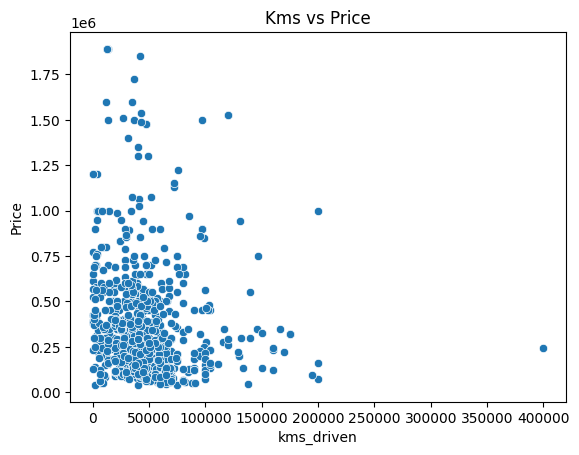

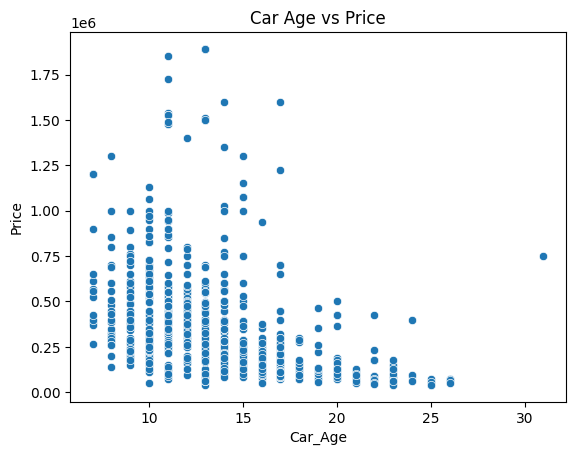

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='kms_driven', y='Price', data=df)
plt.title("Kms vs Price")
plt.show()

sns.scatterplot(x='Car_Age', y='Price', data=df)
plt.title("Car Age vs Price")
plt.show()

In [ ]:
# 6. TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 5. COLUMN SPLIT
# ===============================
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

In [ ]:
# 6. PREPROCESSOR
# ===============================
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

In [ ]:
baseline_models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "RandomForest": RandomForestRegressor(),
    "XGBoost": XGBRegressor(objective='reg:squarederror')
}

print("\n🔹 BASELINE RESULTS")

for name, model in baseline_models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    score = r2_score(np.expm1(y_test), np.expm1(pred))
    print(f"{name}: {score:.4f}")


🔹 BASELINE RESULTS
Linear: 0.6421
Ridge: 0.6215
RandomForest: 0.5718
XGBoost: 0.6019


In [ ]:
print("\n🔹 CV RESULTS")

for name, model in baseline_models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    score = cross_val_score(pipe, X, y, cv=5, scoring='r2').mean()
    print(f"{name}: {score:.4f}")


🔹 CV RESULTS
Linear: 0.6145
Ridge: 0.6210
RandomForest: 0.6247
XGBoost: 0.5993


In [ ]:
grid_results = {}

grid_models = {
    "Ridge": (
        Ridge(),
        {'model__alpha': [1, 10, 50, 100, 200]}
    ),

    "RandomForest": (
        RandomForestRegressor(),
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [3, 5, 7],
            'model__min_samples_split': [5, 10]
        }
    ),

    "XGBoost": (
        XGBRegressor(objective='reg:squarederror'),
        {
            'model__n_estimators': [200, 300],
            'model__max_depth': [3, 5],
            'model__learning_rate': [0.01, 0.05]
        }
    )
}

for name, (model, params) in grid_models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    search = GridSearchCV(pipe, params, cv=5, scoring='r2', n_jobs=-1)
    search.fit(X_train, y_train)

    grid_results[name] = (search.best_estimator_, search.best_score_)

    print(f"Grid {name}: {search.best_score_:.4f}")

Grid Ridge: 0.6193
Grid RandomForest: 0.6217
Grid XGBoost: 0.6750


In [ ]:
rand_results = {}

for name, (model, params) in grid_models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    search = RandomizedSearchCV(
        pipe,
        params,
        n_iter=10,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        random_state=42
    )

    search.fit(X_train, y_train)

    rand_results[name] = (search.best_estimator_, search.best_score_)

    print(f"Random {name}: {search.best_score_:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Random Ridge: 0.6193
Random RandomForest: 0.6232


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Random XGBoost: 0.6750


In [ ]:
# ================================
# 🔥 EXTRA: ADVANCED XGBOOST TUNING (KEEP THIS)
# ================================
model = XGBRegressor(objective='reg:squarederror', random_state=42)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [3, 4],
    'model__learning_rate': [0.03, 0.05],
    'model__subsample': [0.8, 1],
    'model__colsample_bytree': [0.8, 1]
}

search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

search.fit(X_train, y_train)

best_xgb_model = search.best_estimator_

print("\n🔥 Advanced XGBoost CV Score:", search.best_score_)


🔥 Advanced XGBoost CV Score: 0.6713344094433376


In [ ]:
models = {}

# Grid
for name, (model, score) in grid_results.items():
    models[f"Grid_{name}"] = model

# Random
for name, (model, score) in rand_results.items():
    models[f"Random_{name}"] = model


models["Advanced_XGBoost"] = best_xgb_model


In [ ]:
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

def evaluate_model(name, model):

    model.fit(X_train, y_train)

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Convert back
    y_train_actual = np.expm1(y_train)
    y_test_actual = np.expm1(y_test)

    train_pred_actual = np.expm1(train_pred)
    test_pred_actual = np.expm1(test_pred)

    # Scores
    train_r2 = r2_score(y_train_actual, train_pred_actual)
    test_r2 = r2_score(y_test_actual, test_pred_actual)

    cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2').mean()

    gap = train_r2 - test_r2

    print("\n" + "="*60)
    print(f"MODEL: {name}")
    print("="*60)
    print(f"Train R2 : {train_r2:.4f}")
    print(f"CV R2    : {cv_r2:.4f}")
    print(f"Test R2  : {test_r2:.4f}")
    print(f"Gap      : {gap:.4f}")

    return test_r2, cv_r2

In [ ]:
results = []

for name, model in models.items():

    test_score, cv_score = evaluate_model(name, model)

    results.append({
        "Model": name,
        "Test_R2": test_score,
        "CV_R2": cv_score
    })


MODEL: Grid_Ridge
Train R2 : 0.6520
CV R2    : 0.6210
Test R2  : 0.6215
Gap      : 0.0306

MODEL: Grid_RandomForest
Train R2 : 0.6791
CV R2    : 0.6122
Test R2  : 0.5685
Gap      : 0.1106

MODEL: Grid_XGBoost
Train R2 : 0.9229
CV R2    : 0.6461
Test R2  : 0.6273
Gap      : 0.2956

MODEL: Random_Ridge
Train R2 : 0.6520
CV R2    : 0.6210
Test R2  : 0.6215
Gap      : 0.0306

MODEL: Random_RandomForest
Train R2 : 0.6640
CV R2    : 0.6133
Test R2  : 0.5785
Gap      : 0.0856

MODEL: Random_XGBoost
Train R2 : 0.9229
CV R2    : 0.6461
Test R2  : 0.6273
Gap      : 0.2956

MODEL: Advanced_XGBoost
Train R2 : 0.8879
CV R2    : 0.6491
Test R2  : 0.6543
Gap      : 0.2336


In [ ]:
final_model = models["Advanced_XGBoost"]
final_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['company', 'fuel_type'], dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['Car_Age', 'kms_per_year', 'is_luxury', 'age_km_interaction'], dtype='object'))])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

pred = final_model.predict(X_test)

r2 = r2_score(np.expm1(y_test), np.expm1(pred))
rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(pred)))

print("Final R2:", r2)
print("Final RMSE:", rmse)

Final R2: 0.6542850701976247
Final RMSE: 211634.96978483384


In [ ]:
# Predict on full dataset
full_pred = final_model.predict(X)

# Convert back from log
df['Predicted_Price'] = np.expm1(full_pred)

# Actual price
df['Actual_Price'] = df['Price']

print(df[['Actual_Price', 'Predicted_Price']].head())

   Actual_Price  Predicted_Price
0         80000     101696.06250
1        425000     383224.37500
3        325000     299517.65625
4        575000     446300.46875
6        175000     246377.96875


In [ ]:
# Residual = Actual - Predicted
df['Residual'] = df['Actual_Price'] - df['Predicted_Price']

print(df[['Actual_Price', 'Predicted_Price', 'Residual']].head())

   Actual_Price  Predicted_Price      Residual
0         80000     101696.06250  -21696.06250
1        425000     383224.37500   41775.62500
3        325000     299517.65625   25482.34375
4        575000     446300.46875  128699.53125
6        175000     246377.96875  -71377.96875


In [ ]:
print("\nResidual Stats:")
print("Mean Residual :", df['Residual'].mean())
print("Std Residual  :", df['Residual'].std())


Residual Stats:
Mean Residual : 25250.176547851563
Std Residual  : 130693.89239422647


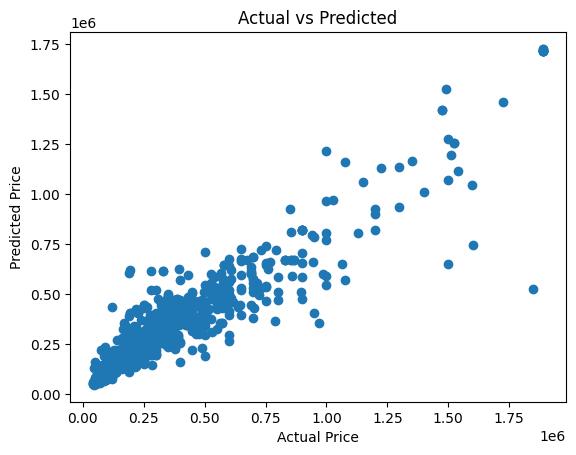

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['Actual_Price'], df['Predicted_Price'])
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

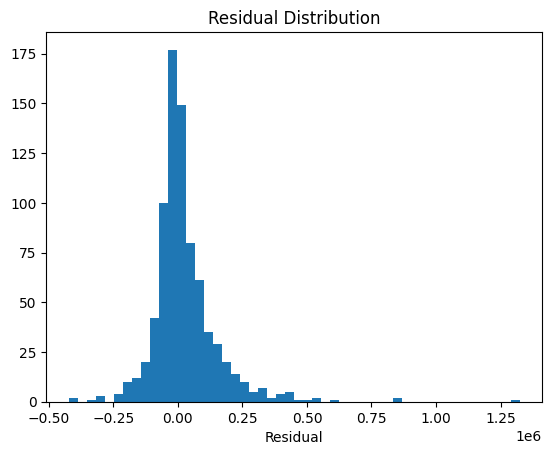

In [ ]:
plt.figure()
plt.hist(df['Residual'], bins=50)
plt.xlabel("Residual")
plt.title("Residual Distribution")
plt.show()

In [ ]:
df.to_csv("final_predictions.csv", index=False)

print("✅ File saved: final_predictions.csv")

✅ File saved: final_predictions.csv
